# Swan Consulting: Customer Churn EDA and Predictive Modelling

## Importing Main Libraries and Loading Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None

import warnings
warnings.filterwarnings('ignore') # ignore pandas warnings

In [2]:
data = pd.read_csv('swan_data.csv')
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## Cleaning

As identified below, the main issue to address are the eleven total charge entries which are a single whitespace (' ') character. These correspond to new customers which have not received their first monthly charge.

In [4]:
data['Total Charges'].value_counts()

Total Charges
20.2      11
          11
19.75      9
19.9       8
19.65      8
          ..
1419.4     1
1990.5     1
7362.9     1
346.45     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [5]:
data[data['Total Charges'] == ' ']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,0,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,0,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,0,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,0,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,0,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,0,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,0,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,0,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,0,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,0,NaN


In [6]:
data['Total Charges'] = data['Total Charges'].str.replace(' ', '0.00')
data['Total Charges'] = data['Total Charges'].astype('float64')

In [7]:
data['CustomerID'].nunique()

7043

In [8]:
data.shape[0]

7043

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data['Churn Reason'].unique()

<StringArray>
[             'Competitor made better offer',
                                     'Moved',
             'Competitor had better devices',
 'Competitor offered higher download speeds',
              'Competitor offered more data',
                            'Price too high',
                   'Product dissatisfaction',
                   'Service dissatisfaction',
           'Lack of self-service on Website',
                       'Network reliability',
                 'Limited range of services',
  'Lack of affordable download/upload speed',
                     'Long distance charges',
                        'Extra data charges',
                                'Don't know',
          'Poor expertise of online support',
           'Poor expertise of phone support',
              'Attitude of service provider',
                'Attitude of support person',
                                  'Deceased',
                                         nan]
Length: 21, dtype: s

In [11]:
data['Payment Method'].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [12]:
df = data.copy()
df.drop(columns=['Count', 'Country', 'State', 'Lat Long', 'Churn Label'], inplace=True)

cleaned_columns = [col.replace(' ', '_').lower() for col in df.columns]
df.columns = cleaned_columns

df.head()

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices


In [13]:
df['churn_value'].value_counts()

churn_value
0    5174
1    1869
Name: count, dtype: int64

In [14]:
df[df['latitude'] == 37.223]

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
1085,2876-VBBBL,Shaver Lake,93664,37.223,-119.001021,Female,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,1,Network reliability
1526,1415-YFWLT,Shaver Lake,93664,37.223,-119.001021,Female,Yes,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,1,Attitude of support person
2489,9146-JRIOX,Shaver Lake,93664,37.223,-119.001021,Female,No,Yes,Yes,14,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,25.55,372.45,0,NaN
3703,1088-AUUZZ,Shaver Lake,93664,37.223,-119.001021,Male,No,Yes,Yes,56,Yes,Yes,DSL,Yes,Yes,No,Yes,No,Yes,Two year,Yes,Credit card (automatic),75.85,4261.20,0,NaN


In [15]:
df[df['zip_code'] == 93664]

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
1085,2876-VBBBL,Shaver Lake,93664,37.223,-119.001021,Female,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,1,Network reliability
1526,1415-YFWLT,Shaver Lake,93664,37.223,-119.001021,Female,Yes,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,1,Attitude of support person
2489,9146-JRIOX,Shaver Lake,93664,37.223,-119.001021,Female,No,Yes,Yes,14,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,25.55,372.45,0,NaN
3703,1088-AUUZZ,Shaver Lake,93664,37.223,-119.001021,Male,No,Yes,Yes,56,Yes,Yes,DSL,Yes,Yes,No,Yes,No,Yes,Two year,Yes,Credit card (automatic),75.85,4261.20,0,NaN


In [16]:
df.drop(columns=['latitude', 'longitude'], inplace=True)
df.head()

,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
0,3668-QPYBK,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved
2,9305-CDSKC,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved
3,7892-POOKP,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved
4,0280-XJGEX,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices


In [17]:
churned = df[df['churn_value'] == 1]
non_churned = df[df['churn_value'] == 0]

In [18]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np

# --- Feature Preparation ---
def prepare_features(group_df):
    """Encode and scale features for clustering."""
    feat = group_df.drop(columns=['customerid', 'city', 'zip_code', 'churn_value', 'churn_reason']).copy()

    # Convert total_charges to numeric
    feat['total_charges'] = pd.to_numeric(feat['total_charges'], errors='coerce')
    feat['total_charges'] = feat['total_charges'].fillna(0)

    # Binary columns: map Yes/No to 1/0
    binary_cols = ['senior_citizen', 'partner', 'dependents', 'phone_service',
                   'multiple_lines', 'online_security', 'online_backup',
                   'device_protection', 'tech_support', 'streaming_tv',
                   'streaming_movies', 'paperless_billing']

    for col in binary_cols:
        feat[col] = feat[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

    # One-hot encode multi-category columns
    feat = pd.get_dummies(feat, columns=['gender', 'internet_service', 'contract', 'payment_method'], drop_first=True, dtype='int')

    # Scale numeric features
    numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
    scaler = StandardScaler()
    feat[numeric_cols] = scaler.fit_transform(feat[numeric_cols])

    return feat

churned_features = prepare_features(churned)
non_churned_features = prepare_features(non_churned)

In [19]:
churned_features.head()

,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,0,-0.818356,1,0,1,1,0,0,0,0,1,-0.835028,-0.753126,1,0,0,0,0,0,0,1
1,0,0,1,-0.818356,1,0,0,0,0,0,0,0,1,-0.151720,-0.730114,0,1,0,0,0,0,1,0
2,0,0,1,-0.511072,1,1,0,0,1,0,1,1,1,1.022272,-0.376284,0,1,0,0,0,0,1,0
3,0,1,1,0.513209,1,1,0,0,1,1,1,1,1,1.231117,0.801058,0,1,0,0,0,0,1,0
4,0,0,1,1.588704,1,1,0,1,1,0,1,1,1,1.186509,1.853924,1,1,0,0,0,0,0,0


In [20]:
non_churned_features.head()

,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
1869,0,1,0,-1.516706,0,0,0,1,0,0,0,0,1,-1.010469,-1.081697,0,0,0,0,0,0,1,0
1870,0,0,0,-0.148061,1,0,1,0,1,0,0,0,0,-0.138796,-0.283471,1,0,0,1,0,0,0,1
1871,0,0,0,0.308154,0,0,1,0,1,1,0,0,0,-0.610014,-0.304397,1,0,0,1,0,0,0,0
1872,0,0,1,-0.645750,1,1,0,1,0,0,1,0,1,0.895310,-0.257760,1,1,0,0,0,1,0,0
1873,0,0,0,-1.143439,0,0,1,0,0,0,0,0,0,-1.013686,-0.964924,0,0,0,0,0,0,0,1


In [21]:
# --- Find Optimal k (Elbow + Silhouette) ---
def find_optimal_k(features, k_range=range(2, 9)):
    inertias = []
    silhouettes = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(features)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(features, labels))
    return list(k_range), inertias, silhouettes

# Evaluate for churned customers
k_vals_churned, inertias_c_churned, silhouettes_c_churned = find_optimal_k(churned_features)

# Evaluate for non-churned customers
k_vals_retained, inertias_c_retained, silhouettes_c_retained = find_optimal_k(non_churned_features)

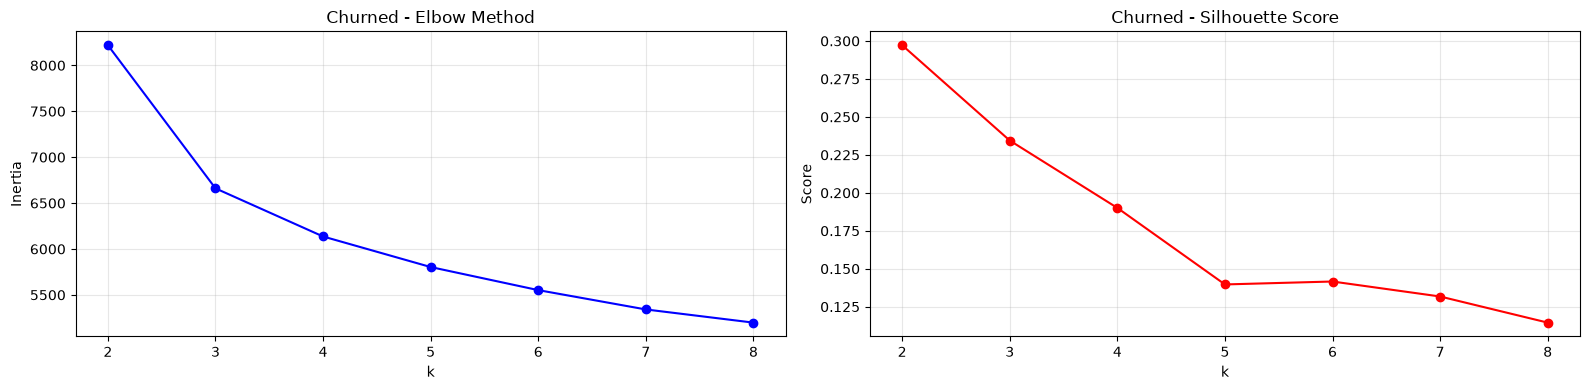

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(k_vals_churned, inertias_c_churned, 'bo-')
axes[0].set_title('Churned - Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_vals_churned, silhouettes_c_churned, 'ro-')
axes[1].set_title('Churned - Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

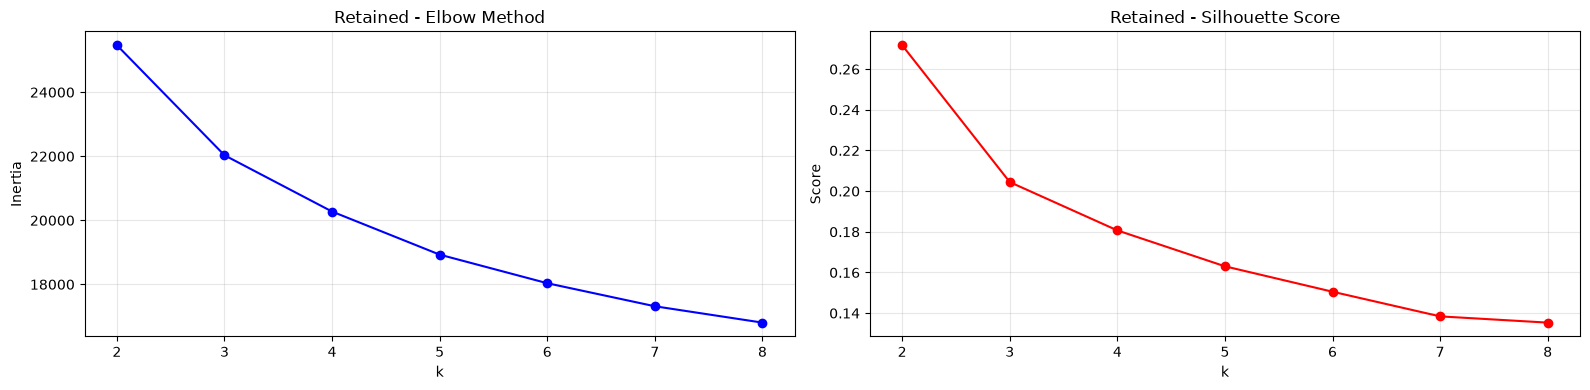

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(k_vals_retained, inertias_c_retained, 'bo-')
axes[0].set_title('Retained - Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_vals_retained, silhouettes_c_retained, 'ro-')
axes[1].set_title('Retained - Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# --- Fit Final Clusters ---
k_churned = 3  # adjust based on elbow/silhouette plots
km_churned = KMeans(n_clusters=k_churned, random_state=42, n_init=10)
churned_labels = km_churned.fit_predict(churned_features) + 1

k_non_churned = 4
km_non_churned = KMeans(n_clusters=k_non_churned, random_state=42, n_init=10)
non_churned_labels = km_non_churned.fit_predict(non_churned_features) + 1

# --- Profile Clusters ---
churned_profiled = churned.copy()
churned_profiled['cluster'] = churned_labels

non_churned_profiled = non_churned.copy()
non_churned_profiled['cluster'] = non_churned_labels

churned_profiled.head()


,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason,cluster
0,3668-QPYBK,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer,1
1,9237-HQITU,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved,3
2,9305-CDSKC,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved,3
3,7892-POOKP,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved,2
4,0280-XJGEX,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices,2


In [25]:
churned_profiled.info()

<class 'pandas.DataFrame'>
RangeIndex: 1869 entries, 0 to 1868
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         1869 non-null   str    
 1   city               1869 non-null   str    
 2   zip_code           1869 non-null   int64  
 3   gender             1869 non-null   str    
 4   senior_citizen     1869 non-null   str    
 5   partner            1869 non-null   str    
 6   dependents         1869 non-null   str    
 7   tenure_months      1869 non-null   int64  
 8   phone_service      1869 non-null   str    
 9   multiple_lines     1869 non-null   str    
 10  internet_service   1869 non-null   str    
 11  online_security    1869 non-null   str    
 12  online_backup      1869 non-null   str    
 13  device_protection  1869 non-null   str    
 14  tech_support       1869 non-null   str    
 15  streaming_tv       1869 non-null   str    
 16  streaming_movies   1869 non-null   

In [26]:
non_churned_profiled.head()

,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason,cluster
1869,7590-VHVEG,Los Angeles,90001,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,NaN,4
1870,5575-GNVDE,Los Angeles,90002,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,NaN,1
1871,7795-CFOCW,Los Angeles,90004,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,NaN,1
1872,1452-KIOVK,Los Angeles,90007,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,NaN,1
1873,6713-OKOMC,Los Angeles,90008,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0,NaN,4


## Churned Cluster Interpretation

### Distribution

In [27]:
def cluster_distribution(profiled_df):
    """
    Show the number and percentage of customers in each cluster.
    Uses seaborn countplot and a styled pie chart.
    Returns a summary DataFrame.
    """
    palette = ['#2c587e', '#a47147', '#d15115']

    dist = profiled_df['cluster'].value_counts().sort_index()
    dist_pct = profiled_df['cluster'].value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        'count': dist,
        'percentage': dist_pct.round(2)
    })
    summary.index.name = 'cluster'

    # Set seaborn style for clean visuals
    sns.set_style('whitegrid')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Countplot (left) ---
    sns.countplot(
        x='cluster',
        data=profiled_df,
        order=sorted(profiled_df['cluster'].unique()),
        palette=palette,
        ax=axes[0],
        edgecolor='black',
        linewidth=0.8
    )
    axes[0].set_title(f'Customer Count by Cluster', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Cluster', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)

    # Add count labels on top of each bar
    for container in axes[0].containers:
        axes[0].bar_label(container, fontsize=10, padding=3)

    # --- Pie chart (right) ---
    n_clusters = len(summary)
    # Cycle through the palette if more clusters than colors
    pie_colors = [palette[i % len(palette)] for i in range(n_clusters)]

    wedges, texts, autotexts = axes[1].pie(
        summary['percentage'],
        labels=[f'Cluster {i}' for i in summary.index],
        autopct='%1.1f%%',
        startangle=90,
        colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 10}
    )
    # Style the percentage text
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    axes[1].set_title(f'Cluster Proportion', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return summary

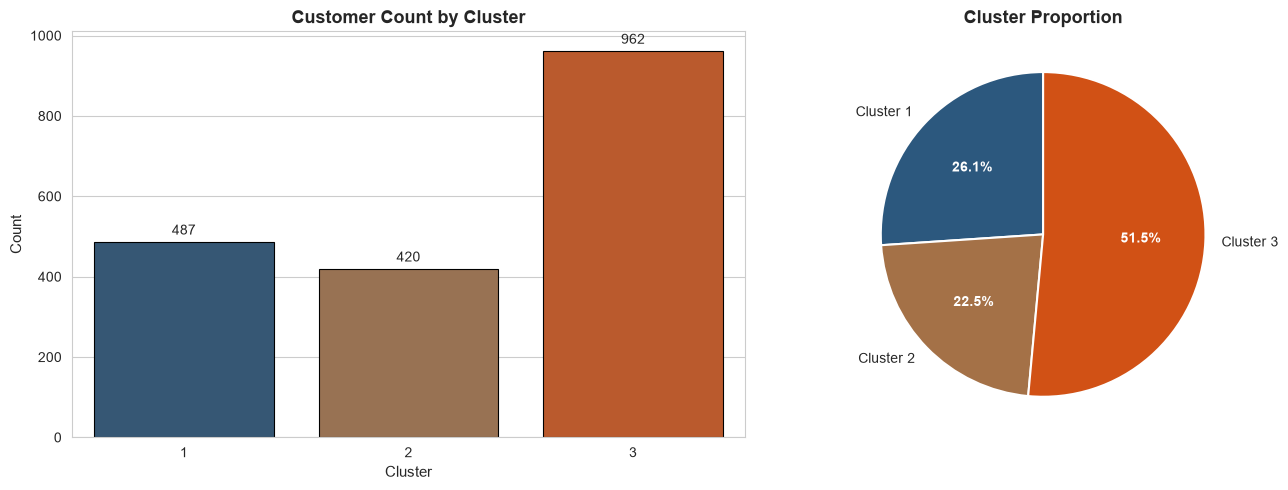

,count,percentage
cluster,,
1,487,26.06
2,420,22.47
3,962,51.47


In [28]:
cluster_distribution(churned_profiled)

### Numeric Features

In [29]:
def numeric_profile_by_cluster(profiled_df):
    """
    Compute and visualize the mean of each numeric feature per cluster.
    Produces a figure with 3 subplots (one per numeric feature) using seaborn barplots.
    Returns the aggregated DataFrame.
    """
    palette = ['#2c587e', '#a47147', '#d15115']

    # Ensure total_charges is numeric
    df_temp = profiled_df.copy()
    df_temp['total_charges'] = pd.to_numeric(df_temp['total_charges'], errors='coerce').fillna(0)

    numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
    agg = df_temp.groupby('cluster')[numeric_cols].mean().round(2)

    # Set seaborn style
    sns.set_style('whitegrid')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for idx, col in enumerate(numeric_cols):
        sns.barplot(
            x='cluster',
            y=col,
            data=df_temp,
            estimator='mean',
            errorbar=None,
            order=sorted(df_temp['cluster'].unique()),
            palette=palette,
            ax=axes[idx],
            edgecolor='black',
            linewidth=0.8
        )

        # Format title nicely
        col_title = col.replace('_', ' ').title()
        axes[idx].set_title(f'{col_title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=10)
        axes[idx].set_ylabel(f'Average {col_title}', fontsize=10)

        # Add value labels on top of each bar
        for container in axes[idx].containers:
            axes[idx].bar_label(container, fmt='%.1f', fontsize=9, padding=3)

    plt.suptitle(f'Average Numeric Features by Cluster', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return agg

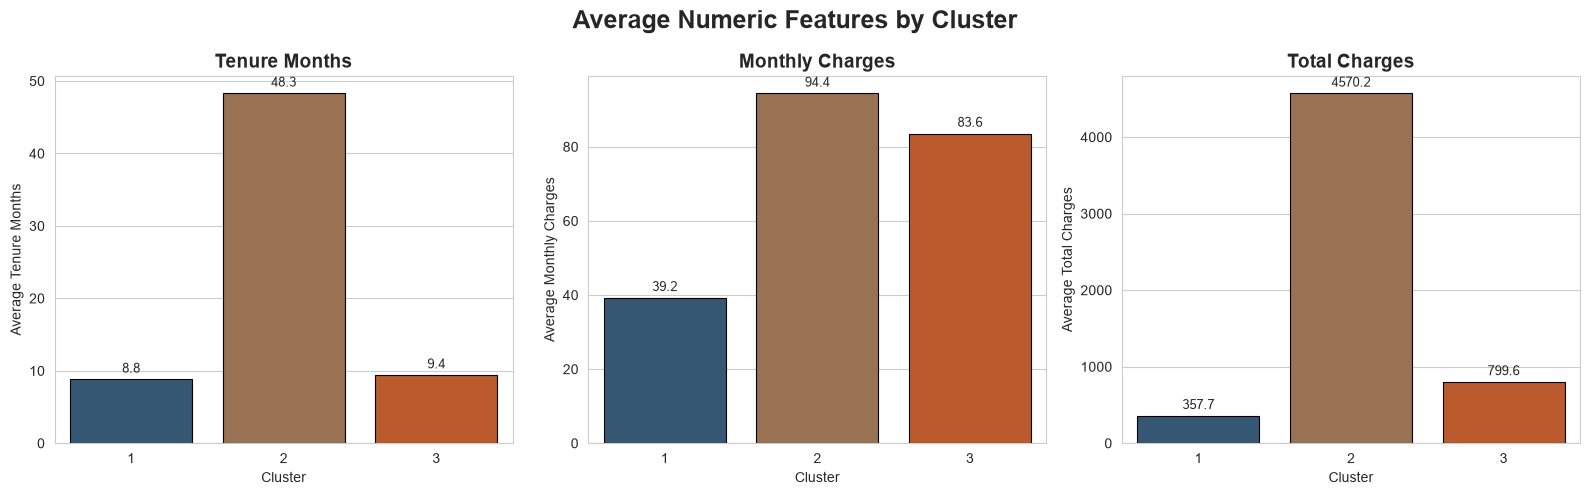

,tenure_months,monthly_charges,total_charges
cluster,,,
1,8.80,39.23,357.67
2,48.29,94.39,4570.20
3,9.39,83.56,799.65


In [30]:
numeric_profile_by_cluster(churned_profiled)

### Categorical Features

In [31]:
def categorical_profile_by_cluster(profiled_df):
    """
    For each key categorical feature, compute the percentage distribution
    within each cluster and visualize with seaborn barplots.
    Clusters are on the x-axis; category values are denoted by color (hue).
    Y-axes are fixed to 0-100%.
    Returns a dict of cross-tab DataFrames keyed by column name.
    """
    palette = ['#2c587e', '#a47147', '#d15115', '#dac3b4']

    cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents',
                'phone_service', 'multiple_lines', 'internet_service',
                'online_security', 'online_backup', 'device_protection',
                'tech_support', 'streaming_tv', 'streaming_movies',
                'contract', 'paperless_billing', 'payment_method']

    cross_tabs = {}

    for col in cat_cols:
        ct = pd.crosstab(profiled_df['cluster'], profiled_df[col], normalize='index') * 100
        cross_tabs[col] = ct

    # Set seaborn style
    sns.set_style('whitegrid')

    n_cols_plot = 2
    n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 5.5 * n_rows_plot))
    axes = axes.flatten()

    for idx, col in enumerate(cat_cols):
        # Melt the cross-tab into long format for seaborn
        ct = cross_tabs[col].copy()
        ct.index.name = 'cluster'
        ct_long = ct.reset_index().melt(id_vars='cluster', var_name=col, value_name='percentage')
        ct_long['cluster'] = ct_long['cluster'].astype(str)

        # Clusters on x-axis, category values as hue (color)
        sns.barplot(
            x='cluster',
            y='percentage',
            hue=col,
            data=ct_long,
            palette=palette[:len(ct.columns)],
            ax=axes[idx],
            edgecolor='black',
            linewidth=0.6
        )

        col_title = col.replace('_', ' ').title()
        axes[idx].set_title(f'{col_title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=9)
        axes[idx].set_ylabel('Percentage (%)', fontsize=9)
        axes[idx].set_ylim(0, 100)
        axes[idx].legend(title=col_title, fontsize=7, title_fontsize=8, loc='upper right')

    # Hide unused subplots
    for idx in range(len(cat_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f'Categorical Feature Distribution by Cluster',
                 fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # return cross_tabs

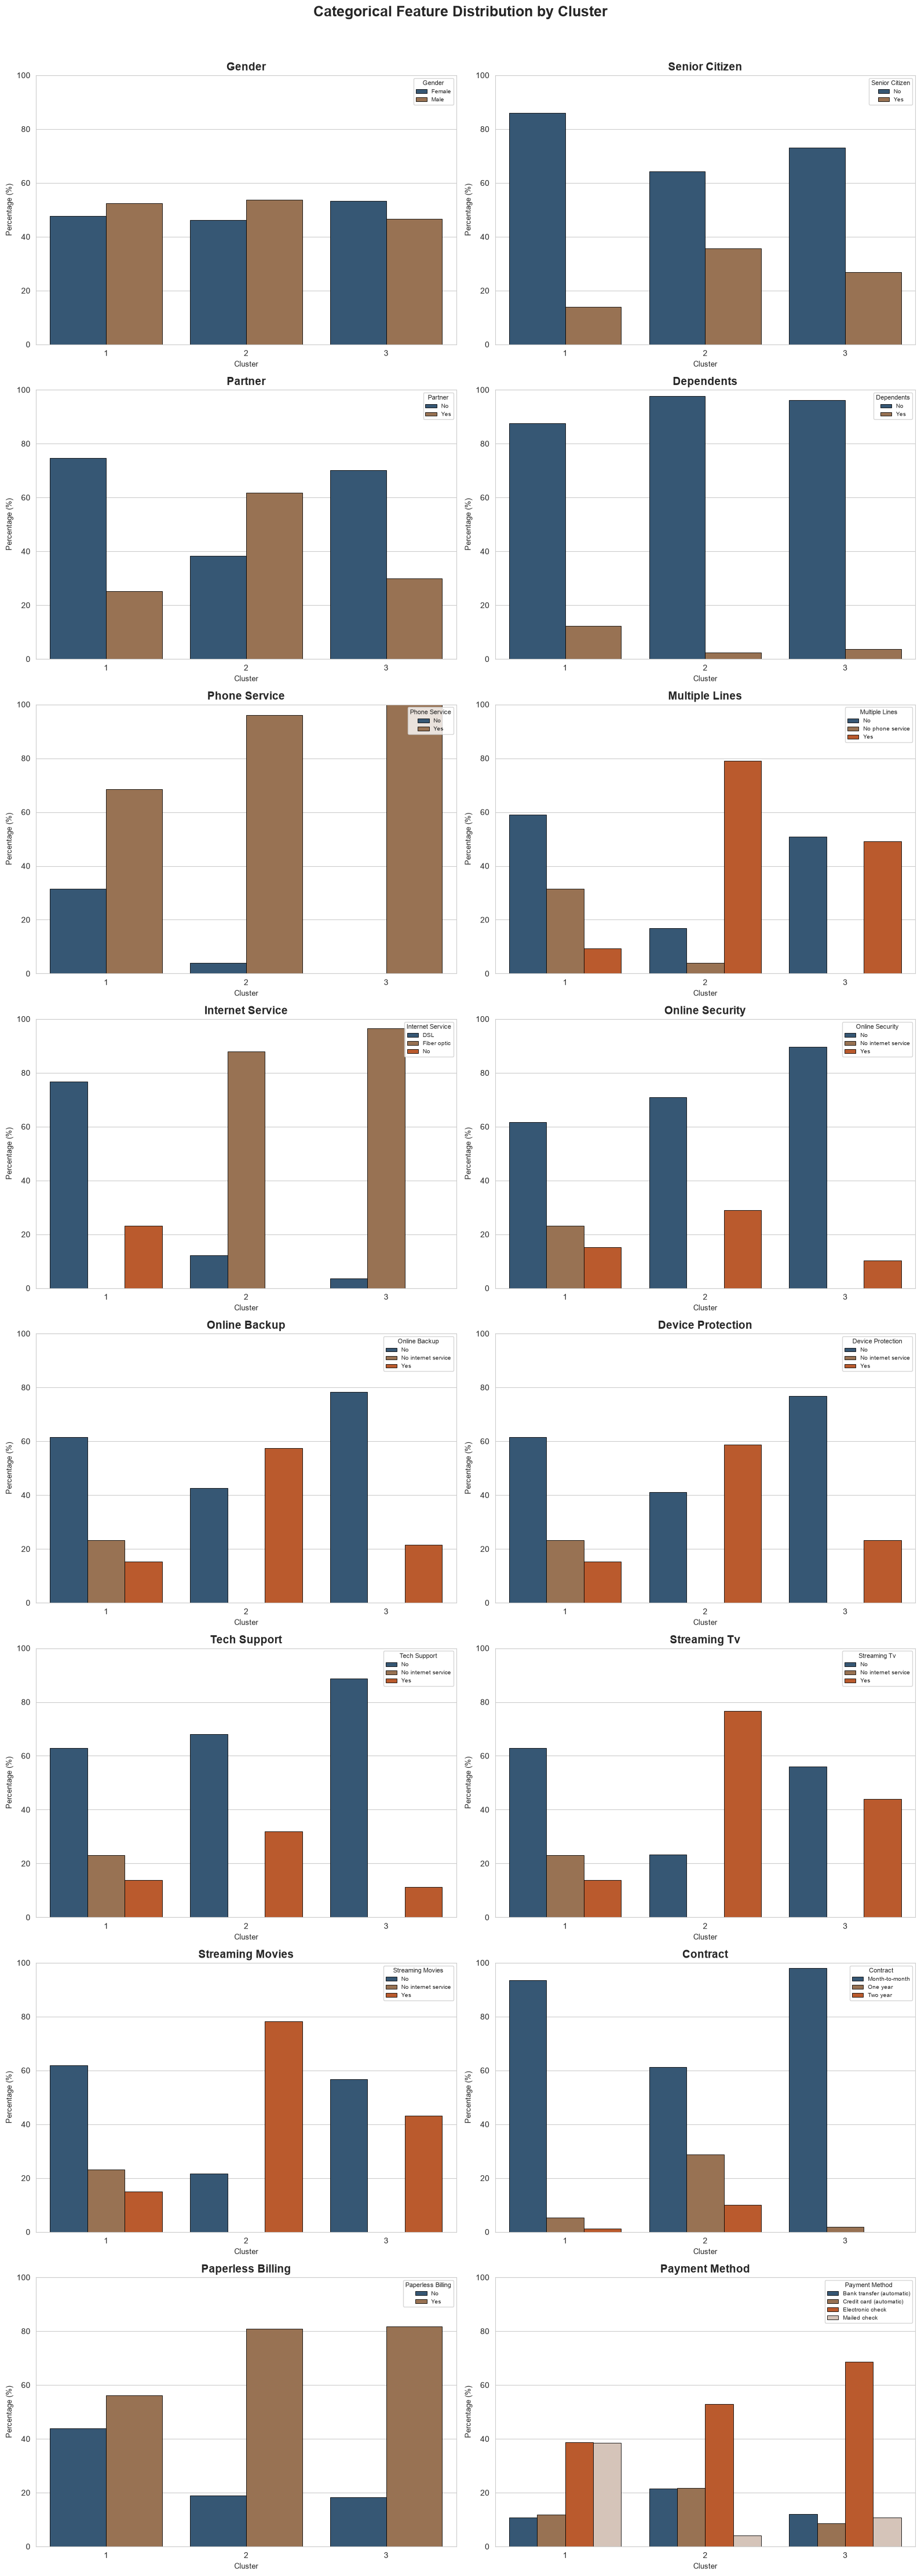

In [32]:
categorical_profile_by_cluster(churned_profiled)

#### Churned Customers: Cluster Profiles

The churned group was segmented into 3 clusters (labeled 1, 2, 3):

| Feature |	Cluster 1 |	Cluster 2 |	Cluster 3 |
|---------|-----------|-----------|-----------|
| Number of Customers | 487 (26.1%) | 420 (22.5%) | 962 (51.5%) |
| Avg Tenure (months) |	Low (~9 months) |	Moderate-Long (~4 years) |	Low (~9 months) |
| Avg Monthly Charges |	Low-medium ($39.20)	| High ($94.40) |	High ($83.60)|
| Avg Total Charges |	Low ($357.70)	| Higher ($4,570.20)	| Low-medium ($799.60) |
| Internet Service |	Mostly DSL / No internet |	Overwhelmingly Fiber optic |	Overwhelmingly Fiber optic |
| Contract |	~93% Month-to-month |	~61% Month-to-month |	~98% Month-to-month |
| Payment Method |	Split between Electronic check & Mailed check	 | ~53% Electronic check |	~69% Electronic check |
| Online Security / Tech Support |	~61% "No" (rest either have it or no internet) |	~70% "No" |	~89-90% "No" |
| Paperless Billing	| ~56% Yes |	~81% Yes |	~82% Yes |
| Senior Citizen |	~14% Yes |	~36% Yes |	~27% Yes |
| Partner / Dependents |	Low partner rate; low dependents |	Higher partner rate; very low dependents |	Low partner; very low dependents |

**Key takeaways for churned customers:**

* Cluster 3 is the most "at-risk" archetype: very short tenure, very high monthly charges, almost exclusively month-to-month contracts, fiber optic internet, paying via electronic check, and virtually no value-added services (online security, tech support, etc.). These are high-revenue but low-loyalty customers.

* Cluster 2 shares many traits with Cluster 3 (fiber optic, high charges, paperless billing, electronic check) but has somewhat longer tenure (4 years on average) and higher add-on adoption. They may represent customers who tried the service longer but still ultimately churned.

* Cluster 1 looks quite different: lower monthly charges, more DSL/no internet, more mailed-check payments, and a high concentration of month-to-month contracts. This group churns despite lower engagement with add-on features, possibly due to price sensitivity on basic services.

---
### Comparison with Retained Customers

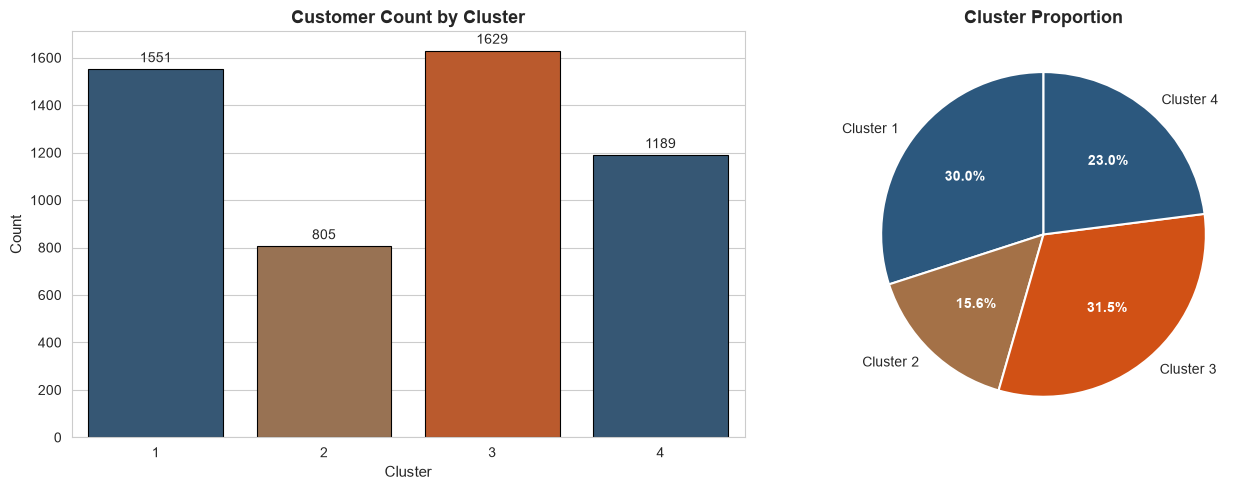

,count,percentage
cluster,,
1,1551,29.98
2,805,15.56
3,1629,31.48
4,1189,22.98


In [33]:
cluster_distribution(non_churned_profiled)

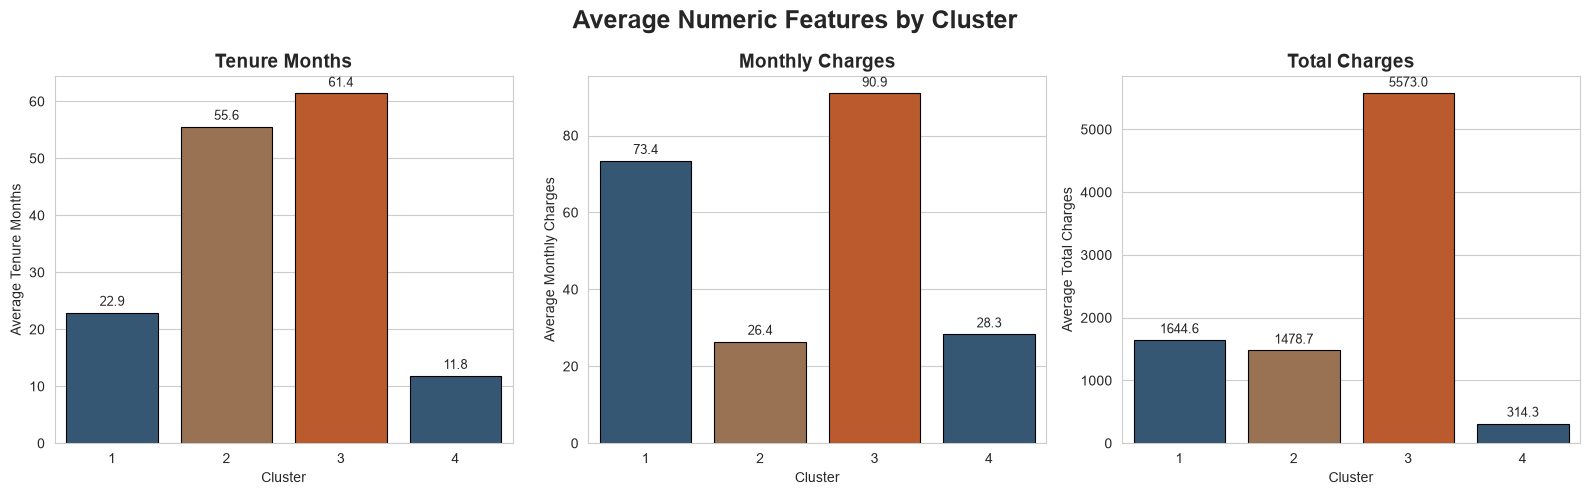

,tenure_months,monthly_charges,total_charges
cluster,,,
1,22.93,73.42,1644.56
2,55.57,26.43,1478.72
3,61.39,90.93,5573.00
4,11.84,28.34,314.35


In [34]:
numeric_profile_by_cluster(non_churned_profiled)

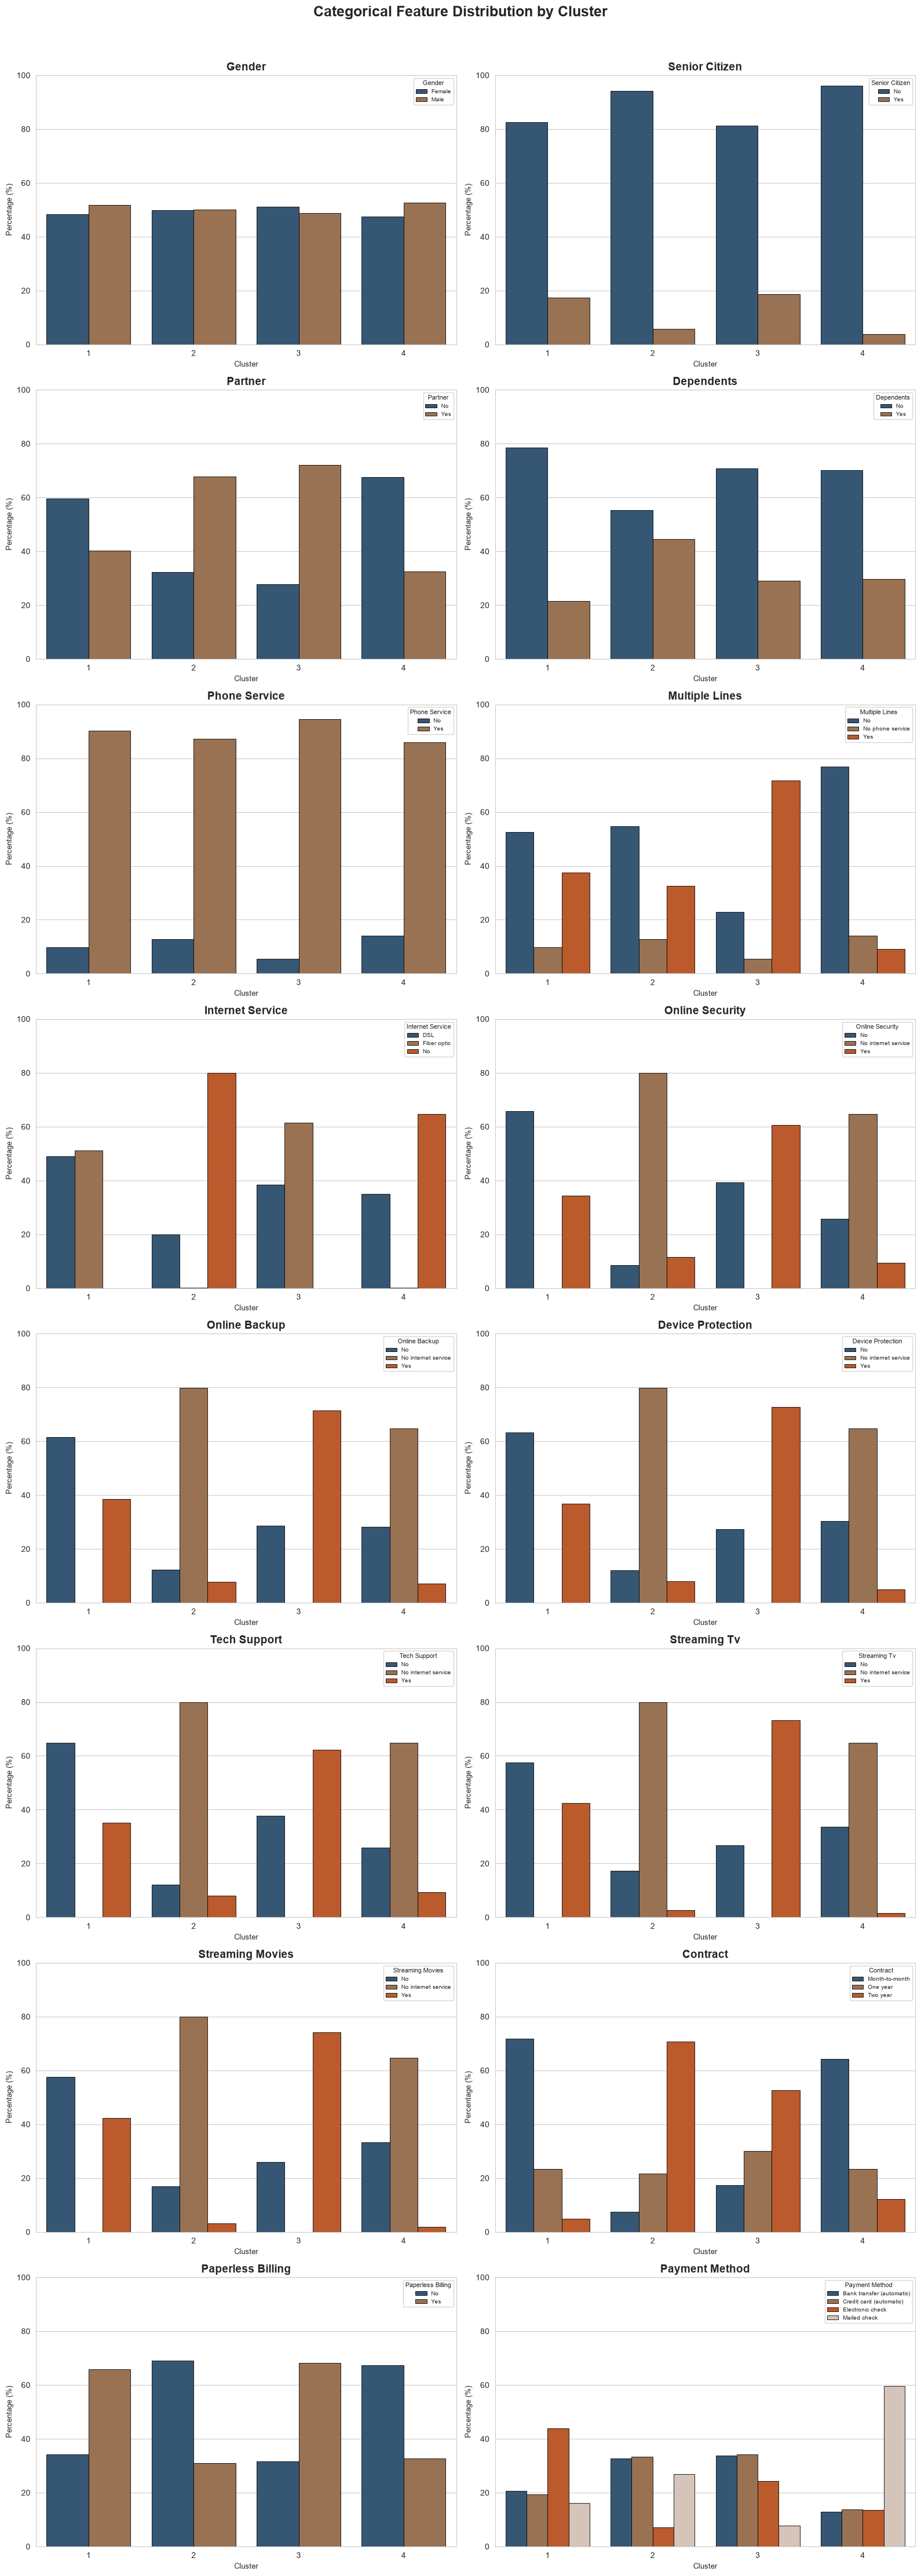

In [35]:
categorical_profile_by_cluster(non_churned_profiled)

#### Non-Churned (Retained) Customers: Cluster Profiles

The retained group was segmented into 4 clusters (labeled 1, 2, 3, 4):

| Feature | Cluster 1 | Cluster 2 | Cluster 3 | Cluster 4 |
|---------|-----------|-----------|-----------|-----------|
| Number of Customers | 1551 (30.0%) | 805 (15.6%) | 1629 (31.5%) | 1189 (23.0%) |
| Avg Tenure (months) | Medium (~23 months) | Long (~56 months) | Long (~61 months) | Short (~12 months) |
| Avg Monthly Charges | High ($73.40) | Low ($26.40) | High ($90.90) | Low ($28.30) |
| Avg Total Charges | Medium ($1,644.60) | Medium ($1,478.70) | High ($5,573.00) | Low ($314.40) |
| Internet Service | ~49% DSL / ~51% Fiber optic | ~80% No internet | ~38% DSL / ~62% Fiber optic | ~35% DSL / ~65% No internet |
| Contract | ~72% Month-to-month | ~71% Two year | ~52% Two year / ~30% One year | ~64% Month-to-month |
| Payment Method | ~44% Electronic check | ~33% Credit card / ~33% Bank transfer | ~34% Credit card / ~34% Bank transfer | ~60% Mailed check |
| Online Security / Tech Support | ~65% "No" | ~80% "No internet service" | ~39–38% "No" / 60–62% "Yes" | ~26% "No" / ~65% "No internet service" |
| Paperless Billing | ~66% Yes | ~31% Yes | ~68% Yes | ~33% Yes |
| Senior Citizen | ~17% Yes | ~6% Yes | ~19% Yes | ~4% Yes |
| Partner / Dependents | ~40% partner; ~22% dependents | ~68% partner; ~45% dependents | ~72% partner; ~29% dependents | ~32% partner; ~30% dependents |


**Key takeaways for retained customers:**

* **Cluster 3** is the "ideal" loyal customer: very long tenure (~5 years), very high monthly charges, overwhelmingly on one-year or two-year contracts, heavy adoption of value-added services (online security, tech support, device protection, online backup, streaming), and pays via automatic bank transfer or credit card. These are **high-value, high-loyalty** customers.

* **Cluster 2** is also very loyal but low-engagement: very long tenure (~56 months), very low monthly charges, mostly no internet service (~80%), overwhelmingly on two-year contracts (~71%), and pays via automatic methods. These likely represent phone-only customers on long-term plans who don't use digital services.

* **Cluster 1** is a "risk" segment among retained customers: medium tenure (~23 months), high charges (mix of fiber optic and DSL), mostly month-to-month contracts (~72%), heavy electronic check payments (~44%), and low adoption of value-added services (~65% don't have online security). Their profile closely mirrors the "at-risk" churned cluster (Cluster 3 in the churned analysis), suggesting they could be future churn candidates.

* **Cluster 4** represents recently-acquired, low-engagement customers: very short tenure (~12 months), low monthly charges, high proportion of no-internet service (~65%), mailed-check payments (~60%), and mostly month-to-month contracts (~64%). They haven't churned yet, but their short tenure and lack of contract lock-in make them potentially vulnerable.


---

### Churn Indicators

Key churn indicators:

1. **Month-to-month contracts** seem to be the strongest churn signal. Every churned cluster is ~93-98% month-to-month, while the most loyal retained cluster (Cluster 3) is predominantly fixed year contracts ~52% two-year/30% one-year. The retained "risk" segment (Cluster 1) that mirrors churned customers is ~72% month-to-month.

2. **Fiber optic + high charges + low tenure** = high-risk combo. Churned Clusters 2 and 3 (74% of all churners) are overwhelmingly fiber optic with high monthly charges. Retained Cluster 3 also has fiber optic and high charges, but the difference is tenure (~5 years vs. ~9 months) and heavy add-on adoption, suggesting fiber/high-price customers only stay if they are also locked into longer contracts and using value-added services.

3. **Lack of value-added services** (online security, tech support) tracks closely with churn. Churned clusters range between 61-90% "No" on these services, while the most stable retained cluster (Cluster 3) shows 60-62% "Yes." Low engagement with these services appears to correlate with disengagement/churn risk generally.

4. **Electronic check payment** is overrepresented among churners. Churned Clusters 2 and 3 lean heavily electronic check (53-69%), while loyal retained customers (Clusters 2 and 3) favor automatic payment methods (credit card/bank transfer, ~33-34% each). Manual payment methods may signal lower commitment or a customer more prone to friction/dropout.

5. **Short tenure + no contract lock-in + high charges** seems to be a churn risk. Retained Cluster 4 has short tenure (~12 months) similar to churned Clusters 1 and 3, but low charges and heavy no-internet/mailed-check usage seem to keep them stable. The combination of short tenure with fiber/high pricing and month-to-month terms appears more dangerous, not tenure by itself.

**Extra note:**

Retained Cluster 1 is the clearest "watchlist" segment out of the retained customer base. The characteristics of this cluster include: 
 - Mid tenure 
 - High charges 
 - Month-to-month 
 - Electronic check 
 - Low add-on adoption
 
which closely resembles the highest-risk churned cluster, making it the most actionable group for proactive retention efforts.